**Purpose:** Aggregate Reddit CV results across v1/v2/v4; picks final_run_v4_h5a8a3d210b as THE model.

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


In [1]:
import json
import os
import matplotlib.pyplot as plt

def process_runs(folder):

    vX_results = [x for x in os.listdir(folder) if x.endswith(".json")]

    # hashes you want to hide
    to_hide_hashes = set()

    runs = []
    for file in vX_results:
        with open(os.path.join(folder, file)) as f:
            d = json.load(f)

        h = d["hparams_hash"]
        if h in to_hide_hashes:
            continue

        runs.append({
            "hash": h,
            "train_f1": d["train_macro_f1_mean_cv"],
            "val_f1": d["val_macro_f1_mean_cv"],
            "hparams": d["hparams"]
        })

    # sort by validation macro f1
    runs.sort(key=lambda r: r["val_f1"], reverse=True)

    return runs

def plot_runs(runs):
    hashes = [r["hash"] for r in runs]
    train = [r["train_f1"] for r in runs]
    val = [r["val_f1"] for r in runs]

    x = range(len(runs))

    plt.figure(figsize=(20, 3))
    plt.ylim(0.6, 0.95)
    plt.plot(x, train, marker="o", label="train_macro_f1")
    plt.plot(x, val, marker="o", label="val_macro_f1")

    plt.xticks(x, hashes, rotation=60)
    plt.ylabel("macro F1")
    plt.xlabel("hparams_hash (sorted by val_macro_f1)")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

    # print hparams under the plot
    for r in runs:
        hp = ", ".join(f"{k}={v}" for k,v in sorted(r["hparams"].items()))
        print(f"{r['hash']}: {hp}")

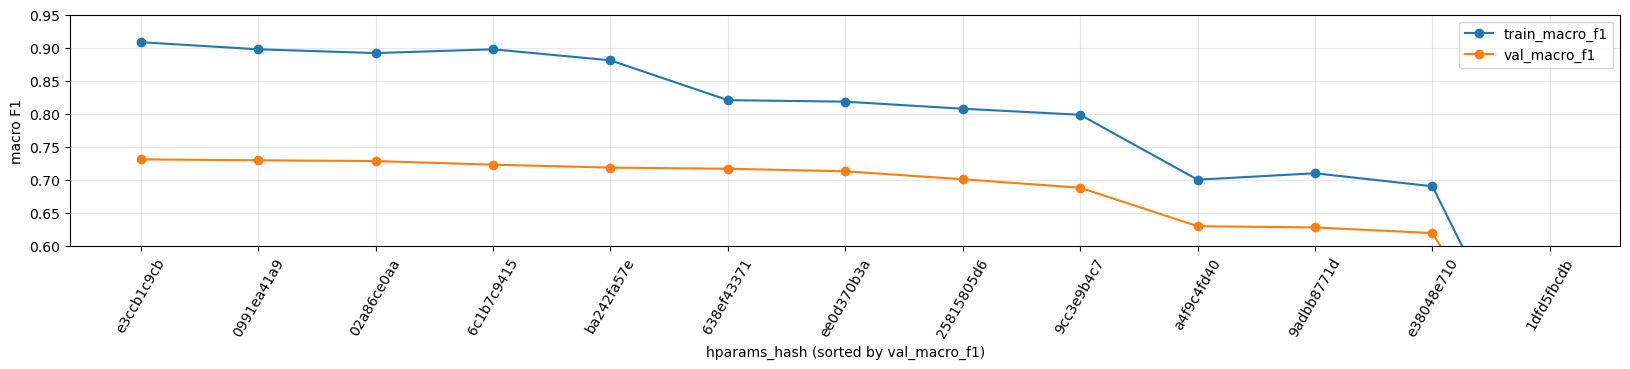

e3ccb1c9cb: dropout=0.1, epochs=3, eval_bs=16, lr=2e-05, max_len=1024, train_bs=8, weight_decay=0
0991ea41a9: dropout=0.3, epochs=3, eval_bs=16, lr=2e-05, max_len=1024, train_bs=8, weight_decay=0.0
02a86ce0aa: dropout=0.3, epochs=3, eval_bs=16, lr=2e-05, max_len=512, train_bs=8, weight_decay=0.01
6c1b7c9415: dropout=0.3, epochs=3, eval_bs=16, lr=2e-05, max_len=2048, train_bs=8, weight_decay=0
ba242fa57e: dropout=0.3, epochs=3, eval_bs=16, lr=2e-05, max_len=1024, train_bs=8, weight_decay=0.01
638ef43371: dropout=0.1, epochs=2, eval_bs=16, lr=2e-05, max_len=1024, train_bs=8, weight_decay=0.005
ee0d370b3a: dropout=0.1, epochs=2, eval_bs=16, lr=2e-05, max_len=512, train_bs=8, weight_decay=0.01
25815805d6: dropout=0.1, epochs=2, eval_bs=16, lr=2e-05, max_len=2048, train_bs=8, weight_decay=0.0001
9cc3e9b4c7: dropout=0.1, epochs=2, eval_bs=16, lr=2e-05, max_len=2048, train_bs=8, weight_decay=0.01
a4f9c4fd40: dropout=0.1, epochs=2, eval_bs=16, lr=1e-05, max_len=2048, train_bs=8, weight_decay=0

In [2]:
plot_runs(process_runs("cv_results_v1"))

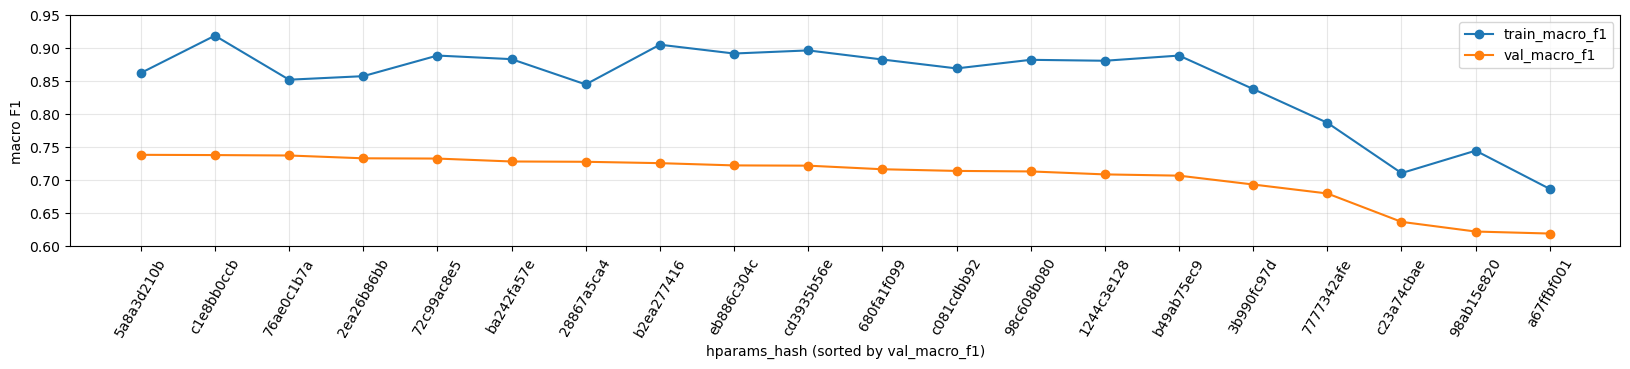

5a8a3d210b: dropout=0.2, epochs=2, eval_bs=16, lr=3e-05, max_len=2048, train_bs=8, weight_decay=0.005
c1e8bb0ccb: dropout=0.2, epochs=3, eval_bs=16, lr=3e-05, max_len=1536, train_bs=8, weight_decay=0.01
76ae0c1b7a: dropout=0.3, epochs=2, eval_bs=16, lr=3e-05, max_len=1536, train_bs=8, weight_decay=0.005
2ea26b86bb: dropout=0.2, epochs=2, eval_bs=16, lr=3e-05, max_len=1536, train_bs=8, weight_decay=0.005
72c99ac8e5: dropout=0.3, epochs=2, eval_bs=4, lr=3e-05, max_len=4096, train_bs=2, weight_decay=0.005
ba242fa57e: dropout=0.3, epochs=3, eval_bs=16, lr=2e-05, max_len=1024, train_bs=8, weight_decay=0.01
28867a5ca4: dropout=0.2, epochs=2, eval_bs=16, lr=3e-05, max_len=1536, train_bs=8, weight_decay=0.007
b2ea277416: dropout=0.2, epochs=3, eval_bs=16, lr=3e-05, max_len=1024, train_bs=8, weight_decay=0.01
eb886c304c: dropout=0.2, epochs=3, eval_bs=16, lr=3e-05, max_len=1536, train_bs=8, weight_decay=0.002
cd3935b56e: dropout=0.3, epochs=3, eval_bs=16, lr=3e-05, max_len=1536, train_bs=8, wei

In [3]:
plot_runs(process_runs("cv_results_v4"))

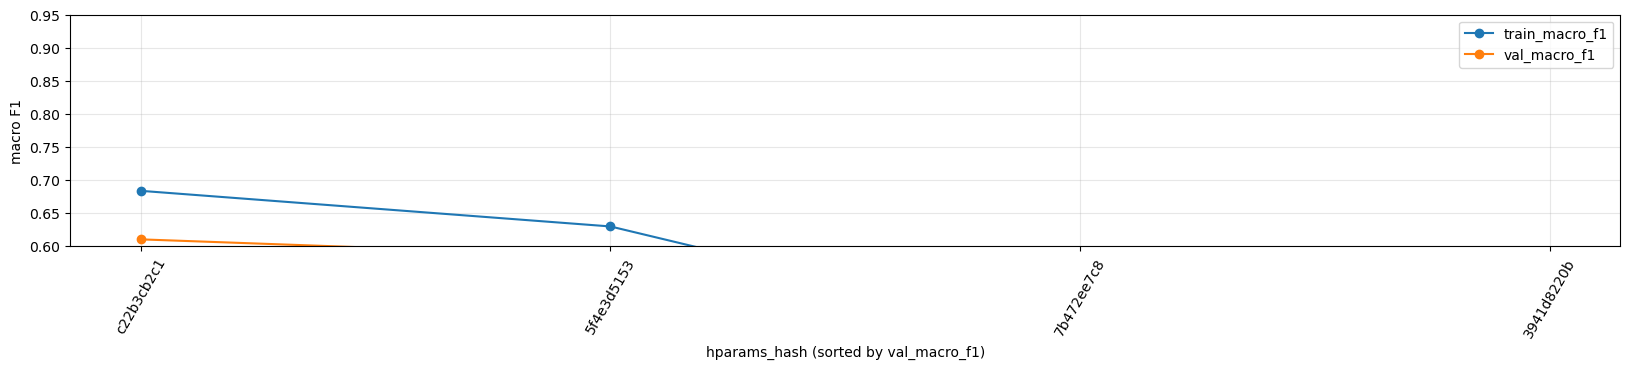

c22b3cb2c1: dropout=0.1, epochs=3, eval_bs=16, gradient_accumulation_steps=4, lr=5e-05, max_len=1024, train_bs=8, unfreeze_last_n_layers=4, weight_decay=0.01
5f4e3d5153: dropout=0.1, epochs=4, eval_bs=16, gradient_accumulation_steps=4, lr=2e-05, max_len=2048, train_bs=8, unfreeze_last_n_layers=4, weight_decay=0.01
7b472ee7c8: dropout=0.1, epochs=2, eval_bs=16, gradient_accumulation_steps=4, lr=2e-05, max_len=512, train_bs=8, unfreeze_last_n_layers=4, weight_decay=0.01
3941d8220b: dropout=0, epochs=3, eval_bs=16, gradient_accumulation_steps=4, lr=5e-06, max_len=1024, train_bs=8, unfreeze_last_n_layers=5, weight_decay=0


In [4]:
plot_runs(process_runs("cv_results_v2"))

### validations/tunning

---

### final run

evaluanting test set (note that it includes only real posts, but also includes disagreement between gpt and llms)

In [5]:
import json
import os

def customf1(model_results_per_sector):
    results_json = [x for x in os.listdir(model_results_per_sector) if x.endswith(".json") and x.startswith("sector_")]

    total_support_train = 0
    total_support_test = 0

    total_f1_train = 0
    total_f1_test = 0

    for results_file in results_json:
        results_file = os.path.join(model_results_per_sector, results_file)
        with open(results_file) as f:
            d = json.load(f)
        
        support_train = d["train"]["classification_report"]["negative"]["support"] + d["train"]["classification_report"]["positive"]["support"]
        support_test = d["test"]["classification_report"]["negative"]["support"] + d["test"]["classification_report"]["positive"]["support"]

        f1_train = d["train"]["classification_report"]["macro avg"]["f1-score"]
        f1_test = d["test"]["classification_report"]["macro avg"]["f1-score"]

        total_support_train += support_train
        total_support_test += support_test

        total_f1_train += f1_train * support_train
        total_f1_test += f1_test * support_test

    
    weighted_f1_train = total_f1_train / total_support_train
    weighted_f1_test = total_f1_test / total_support_test    

    print(f"Custom weighted macro F1 - Train: {weighted_f1_train:.4f}, Test: {weighted_f1_test:.4f}")



customf1("final_run_v4_h5a8a3d210b/per_sector")
customf1("final_run_v4_h76ae0c1b7a/per_sector")

Custom weighted macro F1 - Train: 0.8227, Test: 0.6956
Custom weighted macro F1 - Train: 0.7990, Test: 0.6850


final_run_v4_h5a8a3d210b will be the used one

evaluating where gpt == expected sentiment:

In [6]:
from sklearn.metrics import classification_report, f1_score
from collections import defaultdict
import json

with open("h5a8a3d210b_test.json", "r") as f:
    data = json.load(f)

y_true_global = []
y_pred_global = []

sector_true = defaultdict(list)
sector_pred = defaultdict(list)

for post_id, post in data.items():
    labels = post["label"]

    for sector, info in labels.items():
        expected = info["expected_sentiment"]
        gpt = info["gpt_sentiment"]
        modbert = info["modbert_sentiment"]

        if gpt == expected:  # filter condition
            y_true_global.append(expected)
            y_pred_global.append(modbert)

            sector_true[sector].append(expected)
            sector_pred[sector].append(modbert)

print("GLOBAL METRICS")
print(classification_report(y_true_global, y_pred_global, digits=4))

f1 = f1_score(y_true_global, y_pred_global, average="macro")
print("Weighted F1:", f1)

print("\nPER SECTOR METRICS\n")

for sector in sector_true:
    if len(sector_true[sector]) == 0:
        continue

    f1 = f1_score(
        sector_true[sector],
        sector_pred[sector],
        average="macro"
    )

    print(f"{sector}: macro F1 is {round(f1, 4)} (support {len(sector_true[sector])})")


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\nGLOBAL CONFUSION MATRIX")

labels = sorted(list(set(y_true_global) | set(y_pred_global)))

cm = confusion_matrix(y_true_global, y_pred_global, labels=labels)
print("Labels:", labels)
print(cm)

GLOBAL METRICS
              precision    recall  f1-score   support

    negative     0.7695    0.5881    0.6667       386
     neutral     0.9690    0.9891    0.9789     10176
    positive     0.7857    0.5789    0.6667       456

    accuracy                         0.9581     11018
   macro avg     0.8414    0.7187    0.7708     11018
weighted avg     0.9544    0.9581    0.9551     11018

Weighted F1: 0.7707586982011921

PER SECTOR METRICS

Information Technology: macro F1 is 0.7646 (support 947)
Health Care: macro F1 is 0.8382 (support 1055)
Materials: macro F1 is 0.72 (support 997)
Financials: macro F1 is 0.8053 (support 937)
Utilities: macro F1 is 0.4566 (support 1086)
Communication Services: macro F1 is 0.6756 (support 1041)
Real Estate: macro F1 is 0.7776 (support 1038)
Consumer Staples: macro F1 is 0.3891 (support 1060)
Energy: macro F1 is 0.8694 (support 1045)
Consumer Discretionary: macro F1 is 0.7575 (support 896)
Industrials: macro F1 is 0.7403 (support 916)

GLOBAL CONFU

In [7]:
m1 = str(PROJECT_ROOT / "02_sentiment/reddit/cv_results_v1")

m2 = str(PROJECT_ROOT / "02_sentiment/reddit/cv_results_v2")

m4 = str(PROJECT_ROOT / "02_sentiment/reddit/cv_results_v4")

In [16]:
import json
import os

aaa = [m1, m2, m4]

hparms = {}
used_in = {}

for folder in aaa:
    files = [x for x in os.listdir(folder) if x.endswith(".json")]
    for f in files:
        with open(os.path.join(folder, f)) as file:
            data = json.load(file)

        for hp, value in data["hparams"].items():
            if hp not in hparms:
                hparms[hp] = set()
            hparms[hp].add(value)

            if hp not in used_in:
                used_in[hp] = set()
            used_in[hp].add(folder.split("/")[-1])

hparms.pop("gradient_accumulation_steps", None)  # remove hparams_hash from the dictionary
hparms.pop("unfreeze_last_n_layers", None)  # remove hparams_hash from the dictionary
for hp, values in hparms.items():
    print(f"{hp}: {sorted(values)}")  

# for hp, folders in used_in.items():
#     print(f"{hp} used in: {sorted(folders)}")

lr: [5e-07, 5e-06, 1e-05, 1.5e-05, 2e-05, 3e-05, 4e-05, 5e-05]
weight_decay: [0, 0.0001, 0.002, 0.005, 0.007, 0.01]
dropout: [0, 0.1, 0.15, 0.2, 0.3]
train_bs: [2, 8]
eval_bs: [4, 16]
epochs: [2, 3, 4]
max_len: [512, 1024, 1536, 2048, 4096]
